# Merge Dataset per Training ModernBERT

Unificazione di dataset etichettati per creare un training set coerente:
- **PWC Distilled Balanced** (`pwc_distilled_balanced.csv`, ~28K righe, inglese) — distillato da Ministral 3B
- **Dataset in `data/labelled/`** — caricati dinamicamente via glob (attualmente: `multiclass2.csv`, ~6.5K righe, italiano)

Operazioni:
1. Caricamento dinamico di tutti i CSV in `data/labelled/`
2. Mapping label di ciascun dataset verso lo schema PWC unificato
3. Merge classe "Virtual assistants" in "Enterprise" (PWC + labelled)
4. Deduplicazione per descrizione (multiclass2 ha priorità su multiclass1)
5. Concatenazione in un unico dataset a 9 classi
6. EDA del dataset risultante

**Output:** `data/training/bert_training_dataset.csv`

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Stile grafico
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Caricamento Dati

In [9]:
# --- PWC Distilled ---
df_pwc = pd.read_csv('../data/distilled/pwc_distilled_balanced.csv')

print('=== PWC Distilled Balanced ===')
print(f'Shape: {df_pwc.shape}')
print(f'Colonne: {list(df_pwc.columns)}')
print(f'Classi ({df_pwc["Label"].nunique()}): {sorted(df_pwc["Label"].unique())}')
display(df_pwc.head(3))

# --- Dataset etichettati (data/labelled/) ---
labelled_dir = Path('../data/labelled')
labelled_files = sorted(labelled_dir.glob('*.csv'))
print(f'\nFile trovati in {labelled_dir}: {[f.name for f in labelled_files]}')

dfs_labelled = {}
for fp in labelled_files:
    df_tmp = pd.read_csv(fp)
    dfs_labelled[fp.stem] = df_tmp
    print(f'\n=== {fp.name} ===')
    print(f'Shape: {df_tmp.shape}')
    print(f'Colonne: {list(df_tmp.columns)}')
    label_col = 'Label' if 'Label' in df_tmp.columns else df_tmp.columns[-1]
    print(f'Classi ({df_tmp[label_col].nunique()}): {sorted(df_tmp[label_col].unique())}')
    display(df_tmp.head(3))

=== PWC Distilled Balanced ===
Shape: (28084, 2)
Colonne: ['description', 'Label']
Classi (10): ['Automotive & UVs', 'Enterprise', 'Environment', 'Fintech and Marketing', 'Generic use', 'Healthcare AI', 'Media & Entertainment', 'Research', 'Robotics and Industry', 'Virtual assistants']


,description,Label
0,strong demand for autonomous vehicles and the ...,Automotive & UVs
1,driving simulators play a large role in develo...,Automotive & UVs
2,a key functional block of visual navigation sy...,Automotive & UVs



File trovati in ..\data\labelled: ['multiclass1.csv', 'multiclass2.csv']

=== multiclass1.csv ===
Shape: (6483, 2)
Colonne: ['Descrizione', 'Label']
Classi (9): ['Autonomous driving', 'Data Science', 'Enterprise AI', 'Environmental AI', 'Fintech', 'Healthcare AI', 'Research', 'Robotics AI', 'Virtual assistants']


,Descrizione,Label
0,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,Robotics AI
1,messa a punto di un sistema di Big Data Analyt...,Data Science
2,Implementazione sistemi di AI (artificial inte...,Enterprise AI



=== multiclass2.csv ===
Shape: (6483, 2)
Colonne: ['Descrizione', 'Label']
Classi (10): ['Automotive & UVs', 'Enterprise', 'Environment', 'Fintech and Marketing', 'Generic use', 'Healthcare AI', 'Media & Entertainment', 'Research', 'Robotics and Industry', 'Virtual assistants']


,Descrizione,Label
0,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,Robotics and Industry
1,messa a punto di un sistema di Big Data Analyt...,Enterprise
2,Implementazione sistemi di AI (artificial inte...,Media & Entertainment


## 2. Preprocessing PWC Distilled

In [10]:
# Merge "Virtual assistants" -> "Enterprise"
df_pwc['Label'] = df_pwc['Label'].replace('Virtual assistants', 'Enterprise')
df_pwc['source'] = 'pwc_distilled'

print(f'Classi dopo merge VA ({df_pwc["Label"].nunique()}):')
print(df_pwc['Label'].value_counts())

Classi dopo merge VA (9):
Label
Environment              4000
Generic use              4000
Healthcare AI            4000
Research                 4000
Fintech and Marketing    3648
Robotics and Industry    2467
Automotive & UVs         2409
Enterprise               1867
Media & Entertainment    1693
Name: count, dtype: int64


## 3. Preprocessing Dataset Etichettati

In [12]:
# Mapping unificato: label originale -> label PWC
# Copre label del multiclass2 corrente (schema PWC gia' allineato),
# del multiclass1 e del multiclass2 OLD (schema vecchio, backward compatibility).
# Label mappate a None vengono scartate.
UNIFIED_LABEL_MAP = {
    # === Schema PWC unificato (multiclass2 corrente + futuri dataset) ===
    'Automotive & UVs': 'Automotive & UVs',
    'Enterprise': 'Enterprise',
    'Environment': 'Environment',
    'Fintech and Marketing': 'Fintech and Marketing',
    'Generic use': 'Generic use',
    'Healthcare AI': 'Healthcare AI',
    'Media & Entertainment': 'Media & Entertainment',
    'Research': 'Research',
    'Robotics and Industry': 'Robotics and Industry',
    'Virtual assistants': 'Enterprise',  # merge VA -> Enterprise

    # === Backward compatibility: schema vecchio (multiclass1, multiclass2_OLD) ===
    'Autonomous driving': 'Automotive & UVs',
    'Autonomous Driving and UVs': 'Automotive & UVs',
    'Enterprise AI': 'Enterprise',
    'Environmental AI': 'Environment',
    'Fintech': 'Fintech and Marketing',
    'Robotics AI': 'Robotics and Industry',

    # === Label da scartare ===
    'Data Science': None,
}

# Colonne testo accettate
TEXT_COL_ALIASES = {'Descrizione': 'description', 'description': 'description'}

frames = []
for name, df_tmp in dfs_labelled.items():
    print(f'--- Preprocessing: {name} ---')
    n_start = len(df_tmp)

    # Normalizza colonna testo
    text_col = next((c for c in df_tmp.columns if c in TEXT_COL_ALIASES), None)
    if text_col is None:
        print(f'  SKIP: nessuna colonna testo riconosciuta ({df_tmp.columns.tolist()})')
        continue
    df_tmp = df_tmp.rename(columns={text_col: 'description'})

    # Applica mapping label
    df_tmp['Label'] = df_tmp['Label'].map(UNIFIED_LABEL_MAP)

    # Rimuovi righe con mapping None (es. Data Science)
    n_dropped = df_tmp['Label'].isna().sum()
    if n_dropped > 0:
        print(f'  Rimosse {n_dropped} righe con label scartate')
    df_tmp = df_tmp.dropna(subset=['Label'])

    print(f'  {n_start} -> {len(df_tmp)} righe, {df_tmp["Label"].nunique()} classi')

    df_tmp['source'] = name
    frames.append(df_tmp[['description', 'Label', 'source']])

df_labelled = pd.concat(frames, ignore_index=True)

# Deduplicazione: se descrizioni identiche appaiono in piu' file,
# teniamo l'ultima (ordinamento alfabetico dei file -> multiclass2 > multiclass1)
n_before_dedup = len(df_labelled)
df_labelled = df_labelled.drop_duplicates(subset='description', keep='last')
n_dedup = n_before_dedup - len(df_labelled)
print(f'Deduplicazione: rimossi {n_dedup} duplicati cross-file ({n_before_dedup} -> {len(df_labelled)})')

print(f'Dataset etichettati combinati:')
print(df_labelled['Label'].value_counts())


--- Preprocessing: multiclass1 ---
  Rimosse 101 righe con label scartate
  6483 -> 6382 righe, 7 classi
--- Preprocessing: multiclass2 ---
  6483 -> 6483 righe, 9 classi
Deduplicazione: rimossi 6396 duplicati cross-file (12865 -> 6469)
Dataset etichettati combinati:
Label
Enterprise               2926
Robotics and Industry     942
Healthcare AI             752
Environment               566
Media & Entertainment     456
Fintech and Marketing     298
Research                  204
Generic use               193
Automotive & UVs          132
Name: count, dtype: int64


## 4. Merge dei Dataset

In [13]:
df = pd.concat([df_pwc[['description', 'Label', 'source']],
                df_labelled[['description', 'Label', 'source']]],
               ignore_index=True)

print(f'=== DATASET UNIFICATO ===')
print(f'Righe totali:  {len(df):,}')
print(f'Colonne:       {list(df.columns)}')
print(f'Classi:        {df["Label"].nunique()}')
print(f'Valori nulli:  {df.isnull().sum().sum()}')
print(f'Duplicati:     {df.duplicated(subset="description").sum()}')

print(f'\nContributo per sorgente:')
print(df['source'].value_counts())

print(f'\nDistribuzione classi:')
print(df['Label'].value_counts())

=== DATASET UNIFICATO ===
Righe totali:  34,553
Colonne:       ['description', 'Label', 'source']
Classi:        9
Valori nulli:  0
Duplicati:     3495

Contributo per sorgente:
source
pwc_distilled    28084
multiclass2       6469
Name: count, dtype: int64

Distribuzione classi:
Label
Enterprise               4793
Healthcare AI            4752
Environment              4566
Research                 4204
Generic use              4193
Fintech and Marketing    3946
Robotics and Industry    3409
Automotive & UVs         2541
Media & Entertainment    2149
Name: count, dtype: int64


## 5. Distribuzione delle Classi

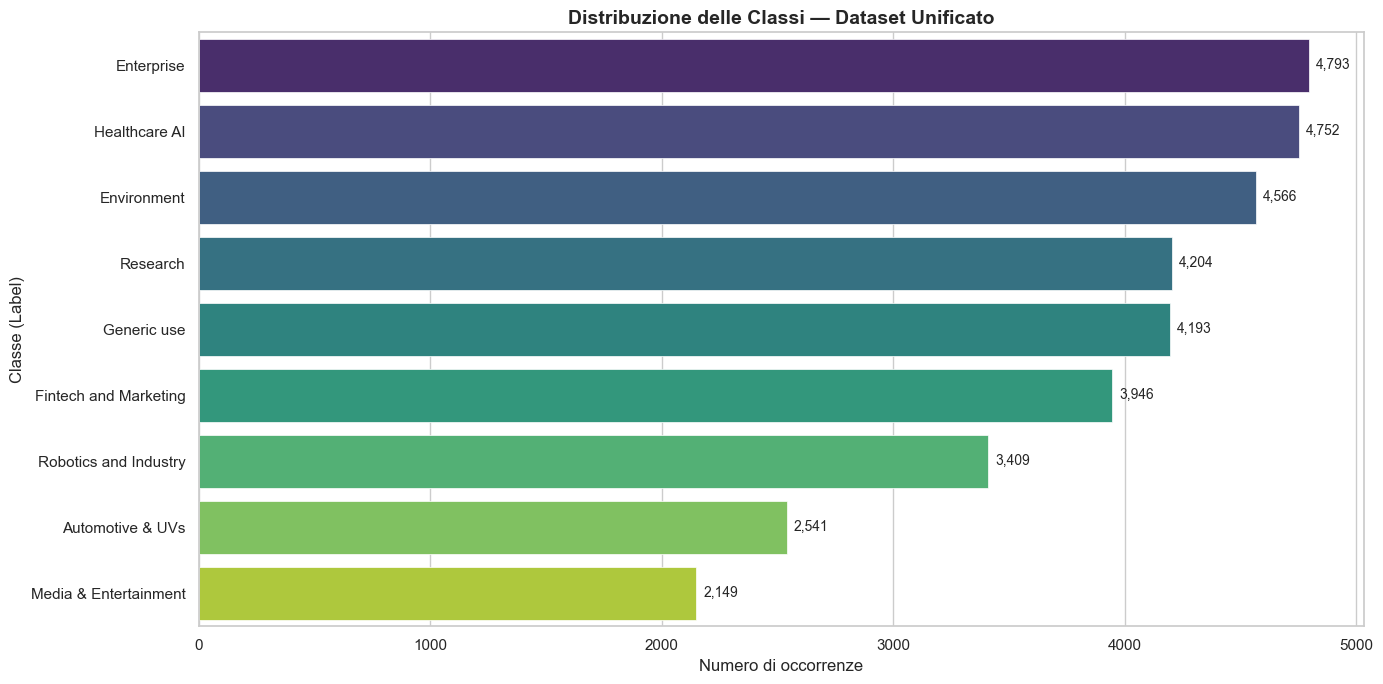

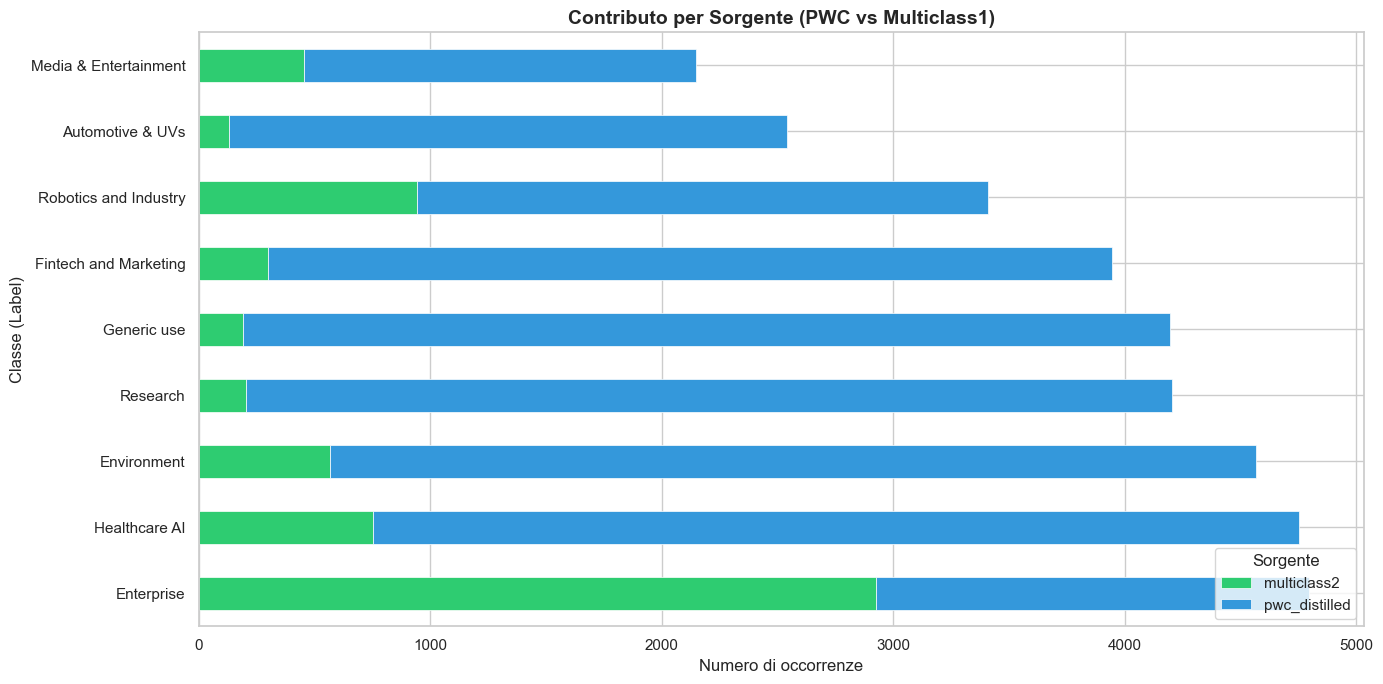

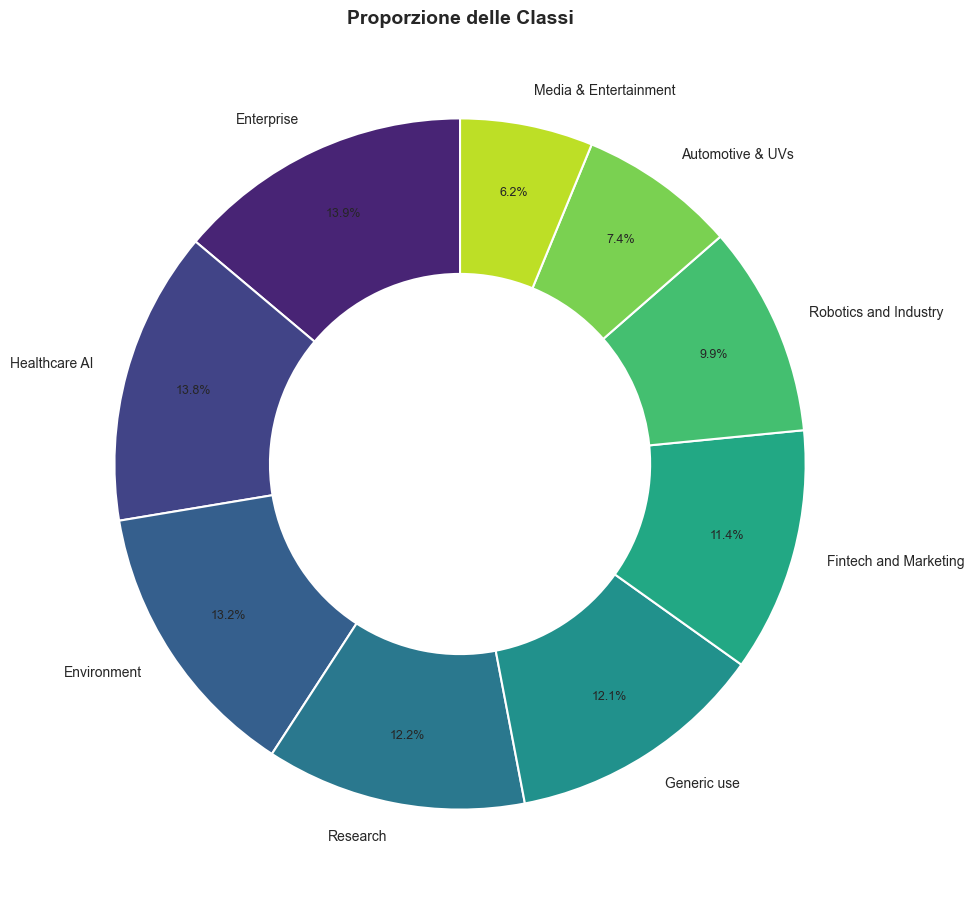

In [14]:
label_order = df['Label'].value_counts().index

# --- Barplot conteggi per classe ---
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, y='Label', order=label_order,
                   palette='viridis', edgecolor='white', linewidth=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=5, fontsize=10)
ax.set_title('Distribuzione delle Classi — Dataset Unificato', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero di occorrenze')
ax.set_ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

# --- Barplot stacked per sorgente ---
cross = pd.crosstab(df['Label'], df['source'])
cross = cross.loc[label_order]

fig, ax = plt.subplots(figsize=(14, 7))
cross.plot.barh(stacked=True, ax=ax, color=['#2ecc71', '#3498db'], edgecolor='white', linewidth=0.5)
ax.set_title('Contributo per Sorgente (PWC vs Multiclass1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero di occorrenze')
ax.set_ylabel('Classe (Label)')
ax.legend(title='Sorgente', loc='lower right')
plt.tight_layout()
plt.show()

# --- Donut chart ---
fig, ax = plt.subplots(figsize=(10, 10))
counts = df['Label'].value_counts()
colors = sns.color_palette('viridis', len(counts))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors, pctdistance=0.8, startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(9)
for t in texts:
    t.set_fontsize(10)
ax.set_title('Proporzione delle Classi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Analisi Lunghezza Descrizioni

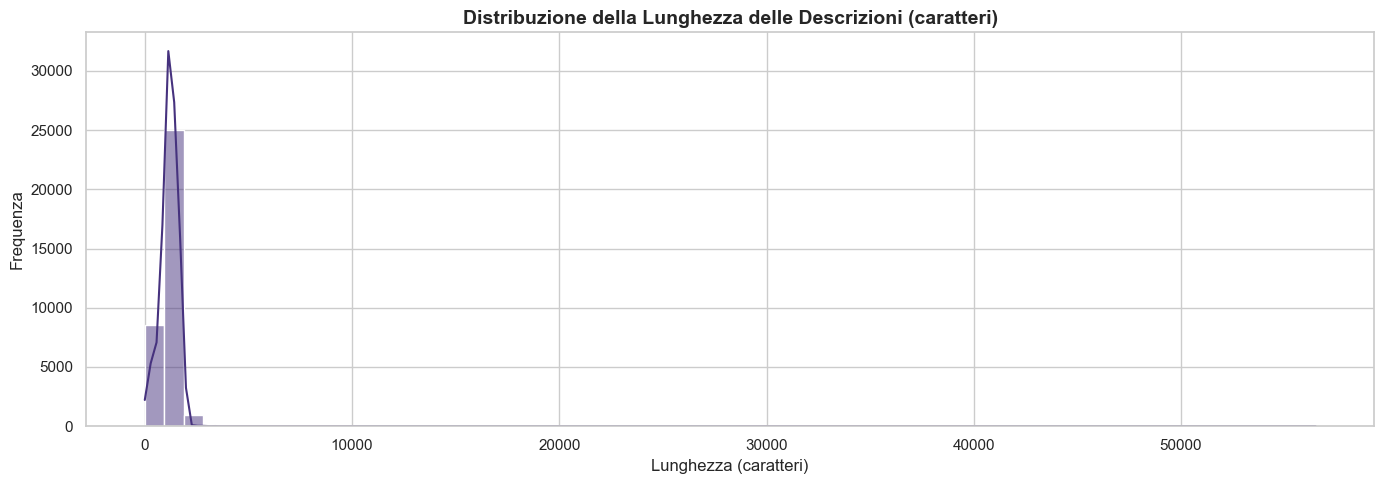

Statistiche globali:


,count,mean,std,min,25%,50%,75%,max
desc_length,34553.0,1176.798078,533.916523,1.0,946.0,1222.0,1464.0,56487.0


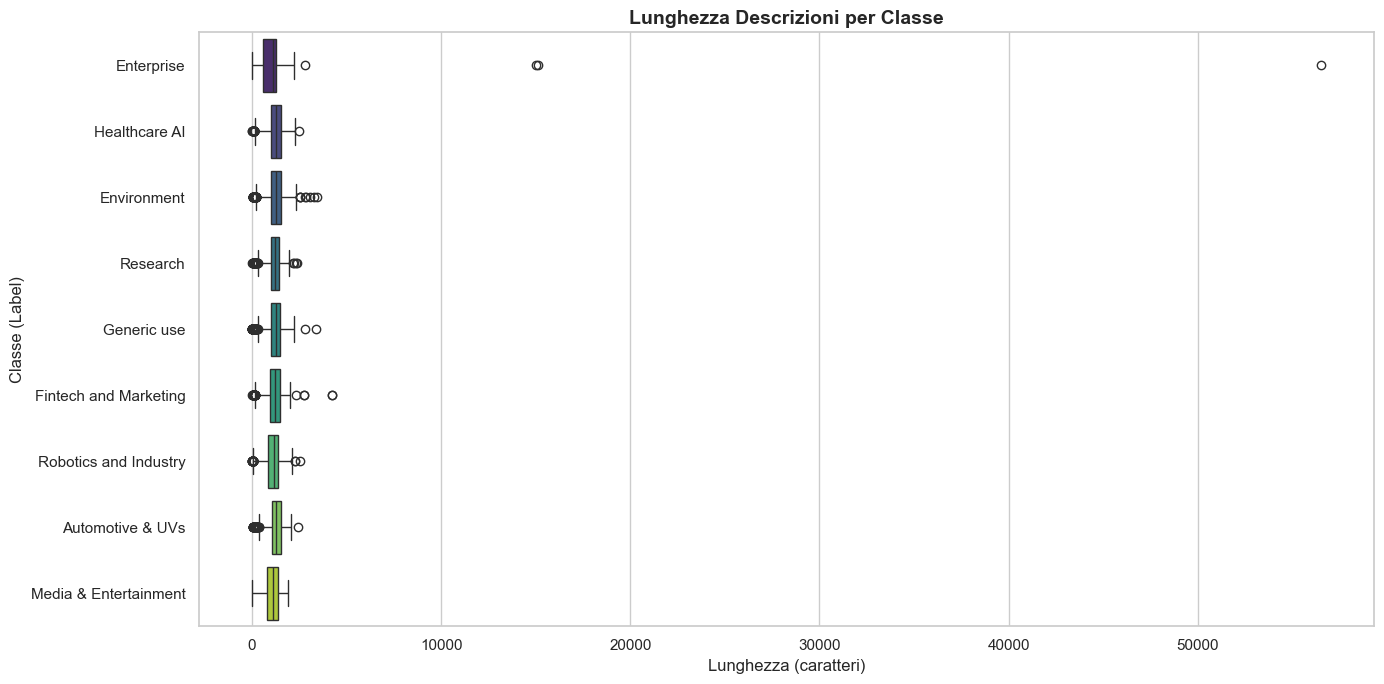

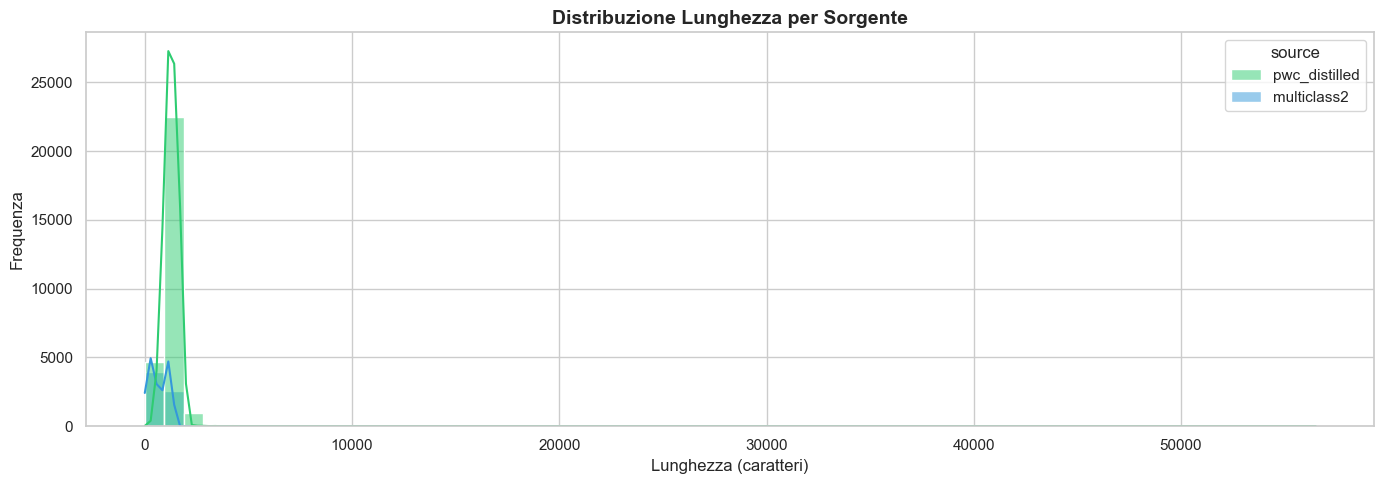


Statistiche per classe:


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Enterprise,4793.0,981.750261,981.130604,7.0,580.0,1090.0,1293.00,56487.0
Healthcare AI,4752.0,1231.232744,435.982911,12.0,987.0,1269.5,1554.00,2483.0
Environment,4566.0,1256.133158,425.652595,38.0,1022.0,1295.0,1561.00,3427.0
Research,4204.0,1206.199334,359.913488,29.0,992.0,1222.0,1444.25,2405.0
Generic use,4193.0,1249.922490,386.221156,1.0,1024.0,1271.0,1505.00,3393.0
Fintech and Marketing,3946.0,1208.059301,392.983032,25.0,951.0,1217.0,1481.00,4218.0
Robotics and Industry,3409.0,1098.246113,445.390143,23.0,867.0,1167.0,1394.00,2568.0
Automotive & UVs,2541.0,1273.369146,347.462989,35.0,1061.0,1284.0,1518.00,2453.0
Media & Entertainment,2149.0,1075.715216,443.833175,18.0,819.0,1133.0,1381.00,1931.0


In [15]:
df['desc_length'] = df['description'].astype(str).str.len()

# Distribuzione globale
plt.figure(figsize=(14, 5))
sns.histplot(df['desc_length'], bins=60, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribuzione della Lunghezza delle Descrizioni (caratteri)', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

print('Statistiche globali:')
display(df['desc_length'].describe().to_frame('desc_length').T)

# Boxplot per classe
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='desc_length', y='Label', order=label_order, palette='viridis')
plt.title('Lunghezza Descrizioni per Classe', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

# Histplot per sorgente
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='desc_length', hue='source', bins=60, kde=True, palette=['#2ecc71', '#3498db'])
plt.title('Distribuzione Lunghezza per Sorgente', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

print('\nStatistiche per classe:')
display(df.groupby('Label')['desc_length'].describe().sort_values('count', ascending=False))

## 7. Metriche di Bilanciamento

Classe maggioritaria: Enterprise (4,793)
Classe minoritaria:   Media & Entertainment (2,149)
Imbalance Ratio:      2.2x

Entropia:                3.127 bit
Entropia max (uniforme): 3.170 bit
Entropia normalizzata:   0.986 (1.0 = perfettamente bilanciato)


,count,%,cumulative_%
Label,,,
Enterprise,4793,13.87,13.87
Healthcare AI,4752,13.75,27.62
Environment,4566,13.21,40.83
Research,4204,12.17,53.00
Generic use,4193,12.13,65.13
Fintech and Marketing,3946,11.42,76.55
Robotics and Industry,3409,9.87,86.42
Automotive & UVs,2541,7.35,93.77
Media & Entertainment,2149,6.22,99.99


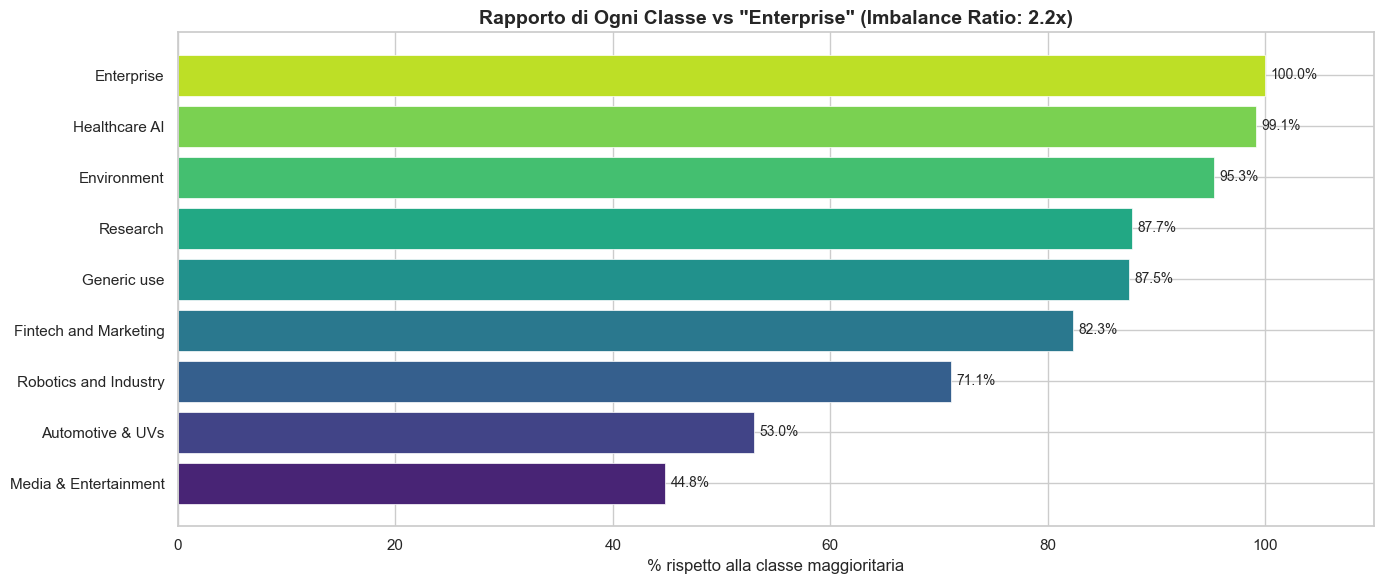

In [16]:
counts = df['Label'].value_counts()
max_class = counts.iloc[0]
min_class = counts.iloc[-1]

# Imbalance ratio
imbalance_ratio = max_class / min_class
print(f'Classe maggioritaria: {counts.index[0]} ({max_class:,})')
print(f'Classe minoritaria:   {counts.index[-1]} ({min_class:,})')
print(f'Imbalance Ratio:      {imbalance_ratio:,.1f}x')

# Entropia normalizzata
probs = counts.values / counts.values.sum()
entropy = -np.sum(probs * np.log2(probs))
max_entropy = np.log2(len(counts))
normalized_entropy = entropy / max_entropy
print(f'\nEntropia:                {entropy:.3f} bit')
print(f'Entropia max (uniforme): {max_entropy:.3f} bit')
print(f'Entropia normalizzata:   {normalized_entropy:.3f} (1.0 = perfettamente bilanciato)')

# Tabella riassuntiva
label_stats = counts.to_frame('count')
label_stats['%'] = (label_stats['count'] / len(df) * 100).round(2)
label_stats['cumulative_%'] = label_stats['%'].cumsum().round(2)
display(label_stats)

# Bar chart rapporto vs maggioritaria
fig, ax = plt.subplots(figsize=(14, 6))
ratios = (counts / max_class * 100).sort_values(ascending=True)
colors = sns.color_palette('viridis', len(ratios))
bars = ax.barh(ratios.index, ratios.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, ratios.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% rispetto alla classe maggioritaria')
ax.set_title(f'Rapporto di Ogni Classe vs "{counts.index[0]}" (Imbalance Ratio: {imbalance_ratio:,.1f}x)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

## 8. Salvataggio

In [17]:
# Drop colonne ausiliarie per il CSV finale
df_out = df[['description', 'Label']].copy()

out_path = Path('../data/training/bert_training_dataset.csv')
df_out.to_csv(out_path, index=False)

print(f'Dataset salvato in: {out_path}')
print(f'Righe:   {len(df_out):,}')
print(f'Classi:  {df_out["Label"].nunique()}')
print(f'\nClassi finali:')
for label in sorted(df_out['Label'].unique()):
    print(f'  - {label}')

# Verifica finale
assert df_out['Label'].nunique() == 9, f'Attese 9 classi, trovate {df_out["Label"].nunique()}'
assert 'Virtual assistants' not in df_out['Label'].values, 'Trovati record Virtual assistants!'
assert 'Data Science' not in df_out['Label'].values, 'Trovati record Data Science!'
print('\nVerifiche superate.')

Dataset salvato in: ..\data\training\bert_training_dataset.csv
Righe:   34,553
Classi:  9

Classi finali:
  - Automotive & UVs
  - Enterprise
  - Environment
  - Fintech and Marketing
  - Generic use
  - Healthcare AI
  - Media & Entertainment
  - Research
  - Robotics and Industry

Verifiche superate.


## Riepilogo

**Operazioni effettuate:**
- Caricamento dinamico di tutti i CSV in `data/labelled/` (attualmente: multiclass1, multiclass2)
- Label mappate allo schema PWC Distilled tramite `UNIFIED_LABEL_MAP`
- "Virtual assistants" fusa in "Enterprise" in tutti i dataset
- Label `None` nel mapping (es. "Data Science") scartate automaticamente
- Deduplicazione per descrizione (multiclass2 ha priorità su multiclass1)
- Dataset concatenati in un unico training set

**Dataset finale:** 9 classi, salvato in `data/training/bert_training_dataset.csv`

## 9. Aggregazione Classi (Automotive, Robotics, Industry)

In questo step caricheremo il dataset finale e uniremo le classi "Automotive & UVs" e "Robotics and Industry" in una singola classe chiamata "Automotive, Robotics, Industry". Il risultato verrà salvato in un nuovo file all'interno della cartella `data/training`.

In [1]:
import pandas as pd
from pathlib import Path

# 1. Carica il file salvato
path_input = Path('../data/training/bert_training_dataset.csv')
df_agg = pd.read_csv(path_input)

# 2. Aggrega le classi
mapping = {
    'Automotive & UVs': 'Automotive, Robotics, Industry',
    'Robotics and Industry': 'Automotive, Robotics, Industry'
}
df_agg['Label'] = df_agg['Label'].replace(mapping)

# 3. Controlla le nuove classi
print("Nuova distribuzione delle label:\n")
print(df_agg['Label'].value_counts())

# 4. Salva il file
path_output = Path('../data/training/bert_training_dataset_aggregated.csv')
df_agg.to_csv(path_output, index=False)

print(f'\nDataset aggregato ({df_agg["Label"].nunique()} classi) salvato in: {path_output}')

Nuova distribuzione delle label:

Label
Automotive, Robotics, Industry    5950
Enterprise                        4793
Healthcare AI                     4752
Environment                       4566
Research                          4204
Generic use                       4193
Fintech and Marketing             3946
Media & Entertainment             2149
Name: count, dtype: int64

Dataset aggregato (8 classi) salvato in: ..\data\training\bert_training_dataset_aggregated.csv
